In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ----------------------------
# 1) Read BECCS BVRE 2021 CSVs
# ----------------------------
urls = {
    "low": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/beccs_BVRE_2021_low.csv",
    "mid": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/beccs_BVRE_2021_mid.csv",
    "high": "https://raw.githubusercontent.com/NREL/ReEDS-2.0/refs/heads/main/inputs/plant_characteristics/beccs_BVRE_2021_high.csv",
}

Columns: ['i', 't', 'capcost', 'fom', 'vom', 'heatrate', 'scenario']
          i       t  capcost     fom    vom  heatrate scenario
0  beccs_90  2010.0  5993.00  161.56  14.81   11.9366     high
1  beccs_99  2010.0  6234.05  161.56  15.90   12.6532     high
2  beccs_90  2011.0  5993.00  161.56  14.81   11.9366     high
3  beccs_99  2011.0  6234.05  161.56  15.90   12.6532     high
4  beccs_90  2012.0  5993.00  161.56  14.81   11.9366     high
Metrics to plot: ['capcost', 'fom', 'vom', 'heatrate']


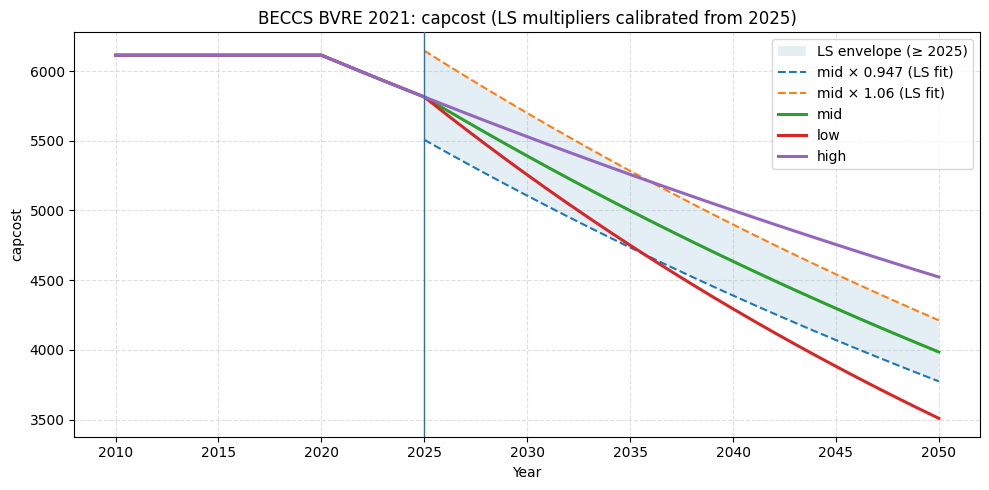

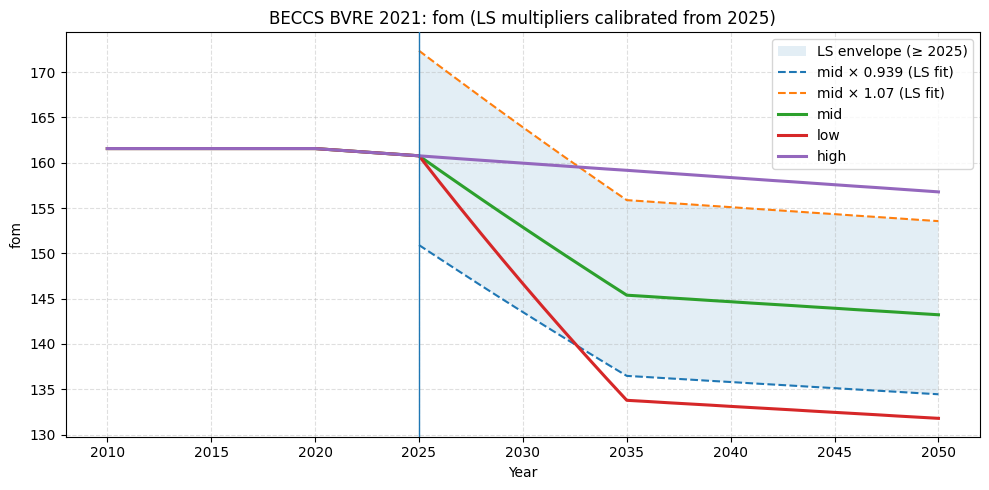

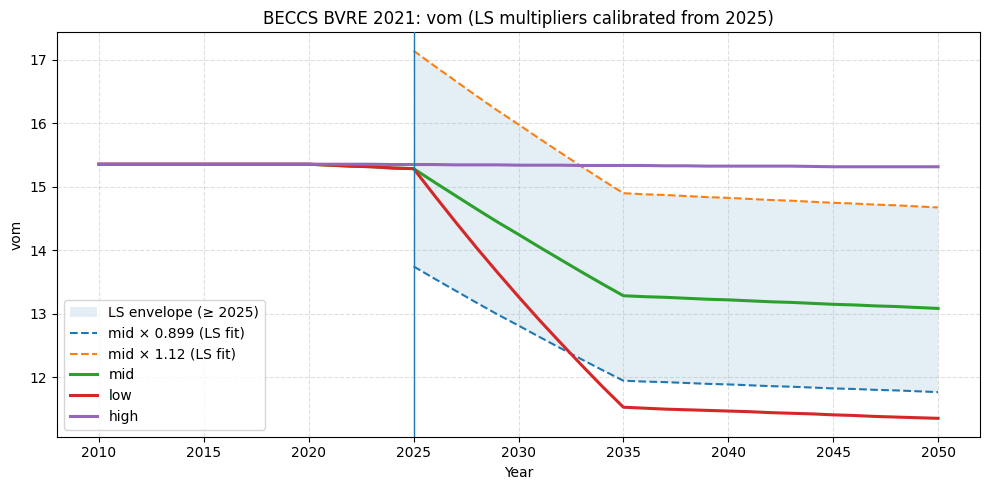

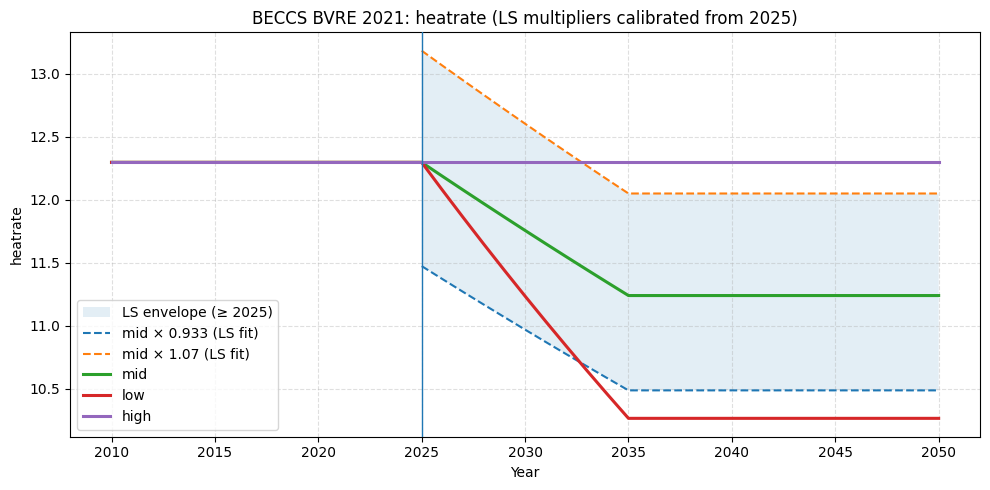

     metric  m_fit_to_low  m_fit_to_high  low_mult  high_mult  cal_years_n
0   capcost      0.947106       1.057039  0.947106   1.057039           26
1       fom      0.938740       1.072144  0.938740   1.072144           26
2       vom      0.899320       1.121461  0.899320   1.121461           26
3  heatrate      0.933027       1.072075  0.933027   1.072075           26


In [4]:



dfs = []
for scen, url in urls.items():
    df = pd.read_csv(url)
    df["scenario"] = scen
    dfs.append(df)

beccs = pd.concat(dfs, ignore_index=True)

# Ensure year column exists and is numeric
beccs["t"] = pd.to_numeric(beccs["t"], errors="coerce")
beccs = beccs.dropna(subset=["t"]).sort_values(["scenario", "t"]).reset_index(drop=True)

print("Columns:", list(beccs.columns))
print(beccs.head())

# ---------------------------------------
# 2) Helpers: LS multiplier + plotting
# ---------------------------------------
def fit_multiplier_ls(M, Y):
    """Least-squares multiplier m = (M·Y)/(M·M)"""
    Mv = M.values.astype(float)
    Yv = Y.values.astype(float)
    denom = np.dot(Mv, Mv)
    return float(np.dot(Mv, Yv) / denom) if denom != 0 else np.nan

def plot_ls_envelope_mid_low_high(df, metric, start_year=2025):
    """
    Baseline: mid
    Target curves: low, high
    Fit two LS multipliers over years >= start_year:
        m_low  = argmin ||m*mid - low||^2
        m_high = argmin ||m*mid - high||^2
    Envelope from start_year onward: mid*m_low to mid*m_high (ordered low/high).
    """
    # Aggregate by 't' and 'scenario' first to handle duplicate entries
    # This takes the mean of the metric for each unique (t, scenario) combination.
    df_agg = df.groupby(['t', 'scenario'])[metric].mean().reset_index()

    piv = (df_agg[["t", "scenario", metric]]
           .dropna(subset=[metric])
           .pivot(index="t", columns="scenario", values=metric)
           .sort_index())

    # Need these scenarios
    for s in ["mid", "low", "high"]:
        if s not in piv.columns:
            raise ValueError(f"Missing scenario '{s}' for metric '{metric}'.")

    # Calibration window
    cal = piv.loc[piv.index >= start_year].dropna(subset=["mid", "low", "high"])
    if cal.empty:
        raise ValueError(f"No calibration data for years >= {start_year} for metric '{metric}'.")

    M = cal["mid"]
    L = cal["low"]
    H = cal["high"]

    mL = fit_multiplier_ls(M, L)
    mH = fit_multiplier_ls(M, H)

    low_mult = min(mL, mH)
    high_mult = max(mL, mH)

    env_low = (piv["mid"] * low_mult).where(piv.index >= start_year, np.nan)
    env_high = (piv["mid"] * high_mult).where(piv.index >= start_year, np.nan)

    # Plot
    plt.figure(figsize=(10, 5))

    # envelope behind
    plt.fill_between(env_low.index, env_low.values, env_high.values,
                     alpha=0.12, zorder=1, label=f"LS envelope (≥ {start_year})")
    plt.plot(env_low.index, env_low.values, "--", zorder=2,
             label=f"mid × {low_mult:.3g} (LS fit)")
    plt.plot(env_high.index, env_high.values, "--", zorder=2,
             label=f"mid × {high_mult:.3g} (LS fit)")

    # scenario lines on top (full timeline)
    plt.plot(piv.index, piv["mid"], linewidth=2.2, zorder=5, label="mid")
    plt.plot(piv.index, piv["low"], linewidth=2.2, zorder=5, label="low")
    plt.plot(piv.index, piv["high"], linewidth=2.2, zorder=5, label="high")

    plt.axvline(start_year, linewidth=1, zorder=6)
    plt.title(f"BECCS BVRE 2021: {metric} (LS multipliers calibrated from {start_year})")
    plt.xlabel("Year")
    plt.ylabel(metric)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {"metric": metric, "m_fit_to_low": mL, "m_fit_to_high": mH,
            "low_mult": low_mult, "high_mult": high_mult, "cal_years_n": int(len(cal))}

# ----------------------------------------------------
# 3) Choose which metrics to visualize
# ----------------------------------------------------
# Prefer these if present (typical ReEDS plant_char fields)
preferred = ["capcost", "fom", "vom", "heatrate", "efficiency", "ccs_rate", "co2_capture_rate"]

available = [c for c in preferred if c in beccs.columns]

# If none of the preferred are present, fall back to all numeric columns except t
if not available:
    numeric_cols = beccs.select_dtypes(include=[np.number]).columns.tolist()
    available = [c for c in numeric_cols if c != "t"]

print("Metrics to plot:", available)

# Plot each selected metric
results = []
for m in available:
    results.append(plot_ls_envelope_mid_low_high(beccs, m, start_year=2025))

# Show fitted multiplier ranges
results_df = pd.DataFrame(results)
print(results_df)
